Zanira Husna G1401231097

Penerapan Metode K-Prototypes dalam Pengelompokan Kabupaten/Kota Berdasarkan Harga Komoditas Pangan

In [346]:
import pandas as pd
import numpy as np
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [347]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [348]:
file_path = '/content/drive/MyDrive/0_df_long.csv'
data = pd.read_csv(file_path, delimiter=";")

# menampilkan 5 baris awal
data.head()

,KabKot,Tahun,Bulan,Produk,Harga,Kategori,KodeBPS,KodeProv,NamaProv
0,Kab. Aceh Barat,2022,Januari,Beras Premium,11429.0,Beras,11.05,11,Aceh
1,Kab. Aceh Barat,2022,Januari,Beras Medium,9979.0,Beras,11.05,11,Aceh
2,Kab. Aceh Barat,2022,Januari,Bawang Merah,31000.0,Bawang,11.05,11,Aceh
3,Kab. Aceh Barat,2022,Januari,Bawang Putih (Bonggol),28636.0,Bawang,11.05,11,Aceh
4,Kab. Aceh Barat,2022,Januari,Cabai Merah Keriting,19409.0,Cabai,11.05,11,Aceh


# Pre-Processing Data

In [349]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340620 entries, 0 to 340619
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   KabKot    340620 non-null  object 
 1   Tahun     340620 non-null  int64  
 2   Bulan     340620 non-null  object 
 3   Produk    340620 non-null  object 
 4   Harga     279107 non-null  float64
 5   Kategori  340620 non-null  object 
 6   KodeBPS   340620 non-null  float64
 7   KodeProv  340620 non-null  int64  
 8   NamaProv  337170 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 23.4+ MB


In [350]:
data.describe(include='all')

,KabKot,Tahun,Bulan,Produk,Harga,Kategori,KodeBPS,KodeProv,NamaProv
count,340620,340620.000000,340620,340620,279107.000000,340620,340620.000000,340620.000000,337170
unique,506,NaN,12,15,NaN,7,NaN,NaN,33
top,Kota Yogyakarta,NaN,September,Beras Premium,NaN,Cabai,NaN,NaN,Jawa Timur
freq,690,NaN,29715,22708,NaN,68124,NaN,NaN,26220
mean,NaN,2023.437599,NaN,NaN,36737.487471,NaN,43.809554,43.596970,NaN
std,NaN,1.094421,NaN,NaN,33129.943834,NaN,25.433926,25.470218,NaN
min,NaN,2022.000000,NaN,NaN,3000.000000,NaN,11.010000,11.000000,NaN
25%,NaN,2022.000000,NaN,NaN,15871.000000,NaN,17.090000,17.000000,NaN
50%,NaN,2023.000000,NaN,NaN,27000.000000,NaN,35.210000,35.000000,NaN
75%,NaN,2024.000000,NaN,NaN,40645.000000,NaN,71.010000,71.000000,NaN


In [351]:
# Menghitung jumlah nilai NaN / null untuk setiap kolom
na_count = data.isna().sum().reset_index()
na_count.columns = ['Kolom', 'Jumlah NA']
na_count

,Kolom,Jumlah NA
0,KabKot,0
1,Tahun,0
2,Bulan,0
3,Produk,0
4,Harga,61513
5,Kategori,0
6,KodeBPS,0
7,KodeProv,0
8,NamaProv,3450


Terdapat data null pada 2 peubah, harga dan nama provinsi

In [352]:
# menentukan kolom yang akan dikecualikan
exclude_cols = ['Harga', 'Tahun', 'Bulan']

# ambil kolom selain yang dikecualikan
selected_cols = [col for col in data.columns if col not in exclude_cols]

# hitung banyaknya nilai unik
unique_count = {col: data[col].nunique(dropna=True) for col in selected_cols}

# tampilkan hasil dalam dataframe
unique_df = pd.DataFrame(list(unique_count.items()), columns=['Kolom', 'Jumlah Unique'])
unique_df


,Kolom,Jumlah Unique
0,KabKot,506
1,Produk,15
2,Kategori,7
3,KodeBPS,505
4,KodeProv,34
5,NamaProv,33


## Prov

Penanganan data null pada kolom nama provinsi

In [353]:
# Group by KodeProv dan lihat nama provinsi yang terkait
prov_check = data.groupby('KodeProv')['NamaProv'].nunique().reset_index()
prov_check.columns = ['KodeProv', 'Jumlah_NamaProv_Unik']
prov_check

,KodeProv,Jumlah_NamaProv_Unik
0,11,1
1,12,1
2,13,1
3,14,1
4,15,1
5,16,1
6,17,1
7,18,1
8,19,1
9,21,1


terindentifikasi bahwa kode provinsi 65 tidak memiliki nama provinsi (null)

In [354]:
prov_mapping = data.groupby('KodeProv')['NamaProv'].unique().reset_index()
prov_mapping.columns = ['KodeProv', 'List_NamaProv']
prov_mapping

,KodeProv,List_NamaProv
0,11,[Aceh]
1,12,[Sumatera Utara]
2,13,[Sumatera Barat]
3,14,[Riau]
4,15,[Jambi]
5,16,[Sumatera Selatan]
6,17,[Bengkulu]
7,18,[Lampung]
8,19,[Kepulauan Bangka Belitung]
9,21,[Kepulauan Riau]


mengecek nama dan kode provinsi apa telah sesuai 1 to 1

In [355]:
# Filter data berdasarkan KodeProv = 65
kabkot_65 = data[data['KodeProv'] == 65][['KabKot', 'KodeProv']]

# Tampilkan hasil
kabkot_65

,KabKot,KodeProv
51165,Kab. Bulungan,65
51166,Kab. Bulungan,65
51167,Kab. Bulungan,65
51168,Kab. Bulungan,65
51169,Kab. Bulungan,65
...,...,...
335095,Kota Tarakan,65
335096,Kota Tarakan,65
335097,Kota Tarakan,65
335098,Kota Tarakan,65


mengecek kota/kab pada kode provinsi 65, terlihat bahwa kode 65 merupakan provinsi kalimantan utara

In [356]:
# Mengisi nilai null pada NamaProv untuk KodeProv = 65
data.loc[(data['KodeProv'] == 65) & (data['NamaProv'].isna()), 'NamaProv'] = 'Kalimantan Utara'

In [357]:
# Menghitung jumlah nilai NaN / null untuk setiap kolom
na_count_65 = data.isna().sum().reset_index()
na_count_65.columns = ['Kolom', 'Jumlah NA']
na_count_65

,Kolom,Jumlah NA
0,KabKot,0
1,Tahun,0
2,Bulan,0
3,Produk,0
4,Harga,61513
5,Kategori,0
6,KodeBPS,0
7,KodeProv,0
8,NamaProv,0


memastikan kolom nama prov sudah terisi

In [388]:
# Menampilkan daftar kabupaten/kota untuk setiap KodeProv
kabkot_per_prov = data.groupby('KodeProv')['KabKot'].unique().reset_index()
kabkot_per_prov.columns = ['KodeProv', 'Daftar_KabKot']
kabkot_per_prov

,KodeProv,Daftar_KabKot
0,11,"[Kab. Aceh Barat, Kab. Aceh Barat Daya, Kab. A..."
1,12,"[Kab. Asahan, Kab. Batu Bara, Kab. Dairi, Kab...."
2,13,"[Kab. Agam, Kab. Dharmasraya, Kab. Kepulauan M..."
3,14,"[Kab. Bengkalis, Kab. Indragiri Hilir, Kab. In..."
4,15,"[Kab. Batang Hari, Kab. Bungo, Kab. Kerinci, K..."
5,16,"[Kab. Banyu Asin, Kab. Empat Lawang, Kab. Laha..."
6,17,"[Kab. Bengkulu Selatan, Kab. Bengkulu Tengah, ..."
7,18,"[Kab. Lampung Barat, Kab. Lampung Selatan, Kab..."
8,19,"[Kab. Bangka, Kab. Bangka Barat, Kab. Bangka S..."
9,21,"[Kab. Bintan, Kab. Karimun, Kab. Kepulauan Ana..."


melihat kota/kab apa saja untuk setiap provinsi

## Harga

mengisi data null pada harga dengan rata-rata produk tersebut di provinsi yang sama

In [359]:
null_count_kabkot = (data[data['Harga'].isna()]
                     .groupby('KabKot')
                     .size()
                     .reset_index(name='Jumlah_NA'))

null_count_kabkot.sort_values(by='Jumlah_NA', ascending=False)

,KabKot,Jumlah_NA
153,Kab. Kepulauan Seribu,262
92,Kab. Dogiyai,247
5,Kab. Aceh Singkil,222
390,Kab. Toba,217
401,Kab. Waropen,217
...,...,...
308,Kab. Puncak,34
130,Kab. Kaimana,33
406,Kab. Yalimo,22
313,Kab. Raja Ampat,13


In [360]:
null_detail = (data[data['Harga'].isna()]
               .groupby(['KabKot','Produk'])
               .size()
               .reset_index(name='Jumlah_NA'))

null_detail

,KabKot,Produk,Jumlah_NA
0,Kab. Aceh Barat,Cabai Merah Besar,44
1,Kab. Aceh Barat,Cabai Rawit Merah,19
2,Kab. Aceh Barat,Jagung Tk. Peternak,43
3,Kab. Aceh Barat,Minyak Goreng Curah,3
4,Kab. Aceh Barat,Minyakita,36
...,...,...,...
2336,Kota Tual,Minyakita,36
2337,Kota Yogyakarta,Cabai Merah Besar,36
2338,Kota Yogyakarta,Jagung Tk. Peternak,40
2339,Kota Yogyakarta,Minyak Goreng Curah,3


In [361]:
# Mengimputasi harga berdasarkan mean grup (Produk, KodeProv)
data['Harga'] = data.groupby(['Produk', 'KodeProv'])['Harga']\
                    .transform(lambda x: x.fillna(x.mean()))


In [362]:
data['Harga'].isna().sum()

np.int64(0)

# EDA

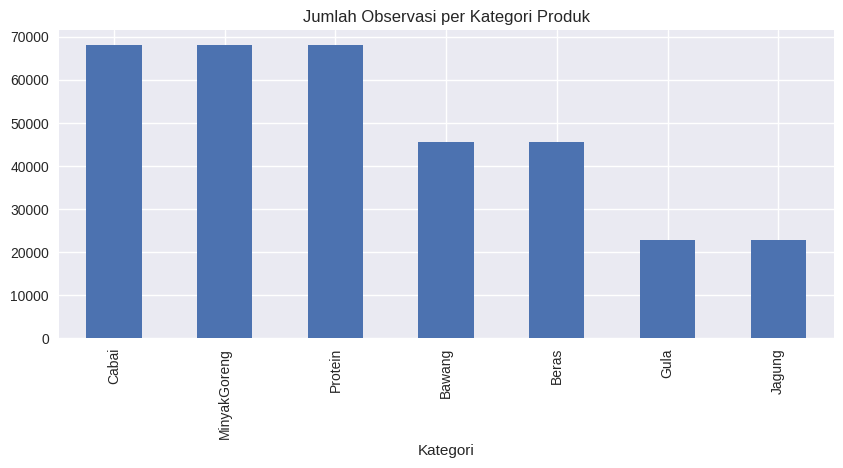

In [363]:
# Total observasi per kategori produk
plt.figure(figsize=(10,4))
data['Kategori'].value_counts().plot(kind='bar')
plt.title("Jumlah Observasi per Kategori Produk")
plt.show()

terlihat bahwa pada data, paling banyak merupakan kategori cabai, minyak goreng dan protein yang tidak jauh berbeda satu sama lain. kemudian disusul bawang dan beras, lalu terakhir ada gula dan jagung

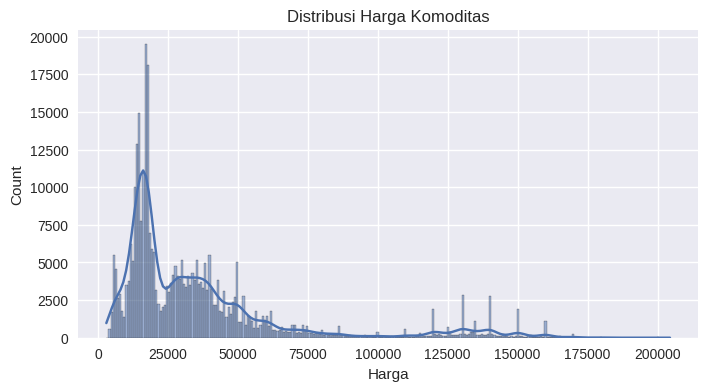

In [364]:
# Distribusi harga
plt.figure(figsize=(8,4))
sns.histplot(data['Harga'], kde=True)
plt.title("Distribusi Harga Komoditas")
plt.show()

secara keseluruhan data komoditas berada di rentang 0-75.000 namun terdapat beberapa pencilan di 125.000-175.000

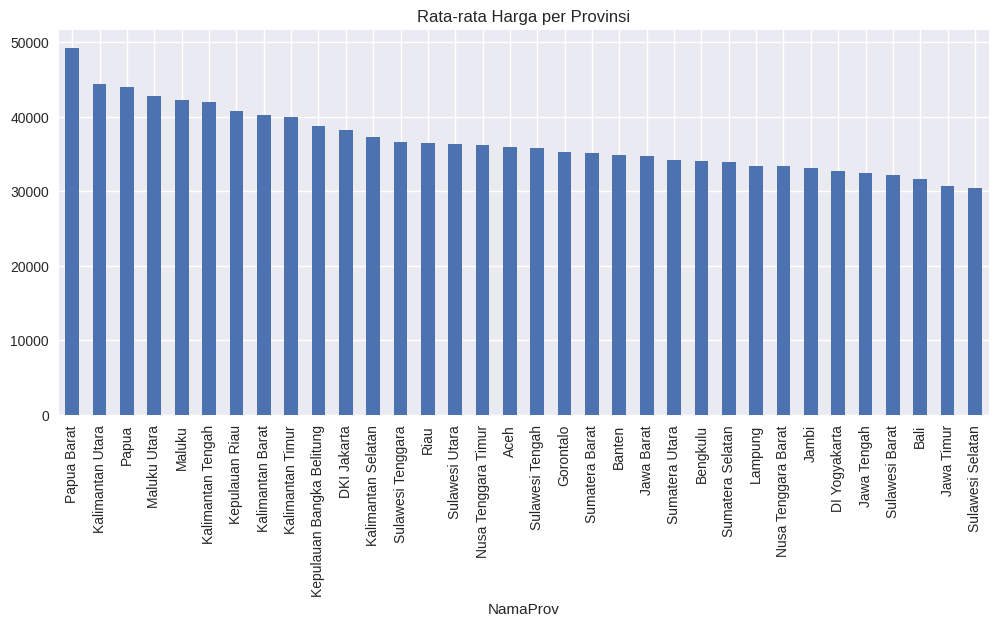

In [365]:
# Harga rata-rata per provinsi
avg_prov = data.groupby("NamaProv")['Harga'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,5))
avg_prov.plot(kind='bar')
plt.title("Rata-rata Harga per Provinsi")
plt.show()

secara keseluruhan harga komoditas pangan di papua barat meiliki harga tertinggi. sedangkan terendah terdapat di sulawesi selatan.

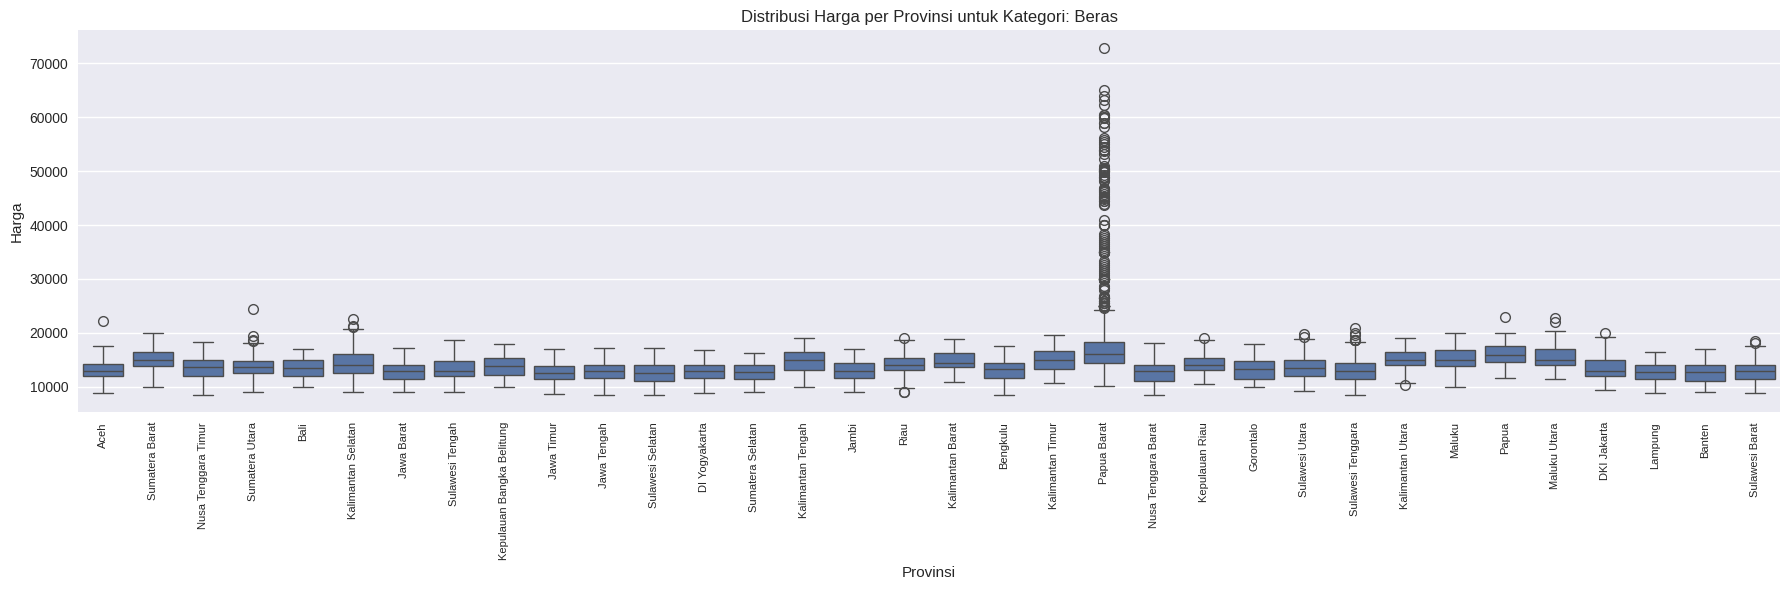

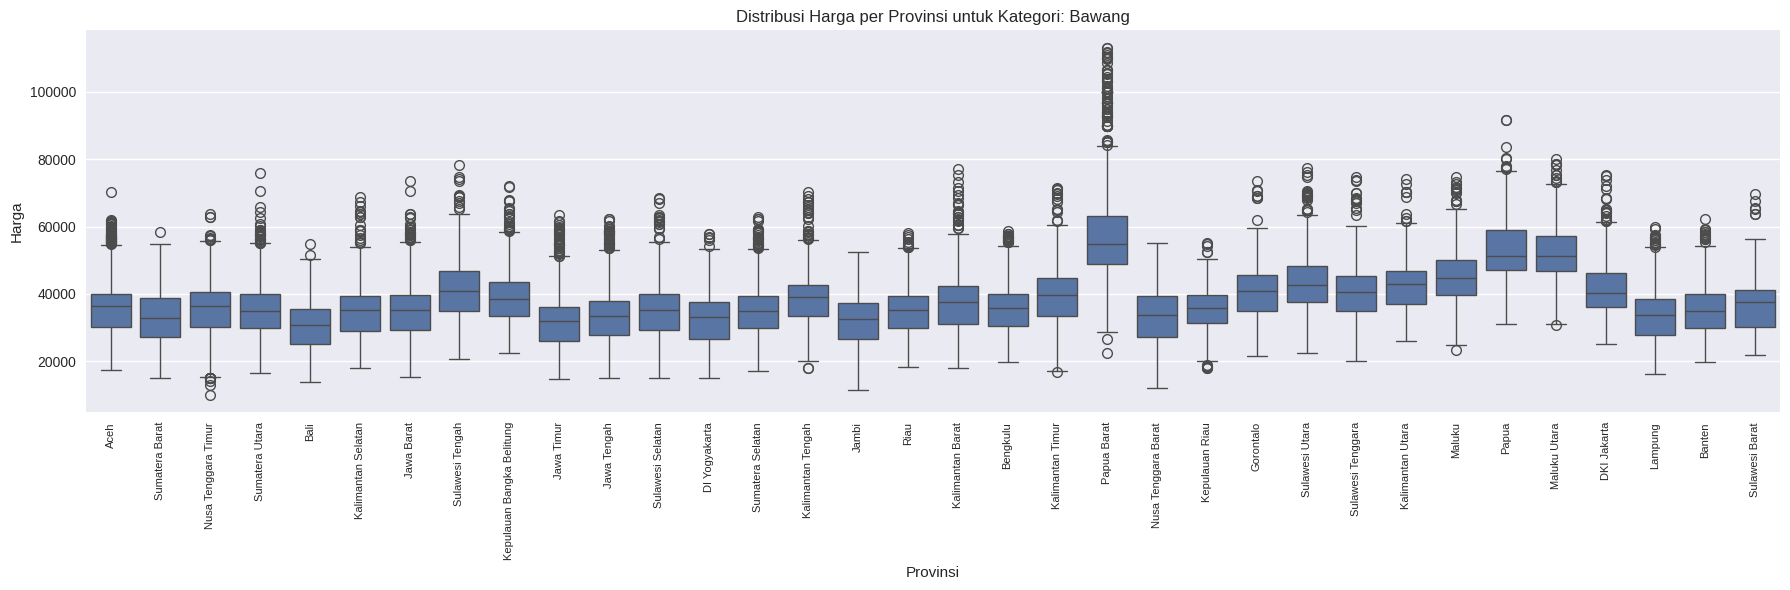

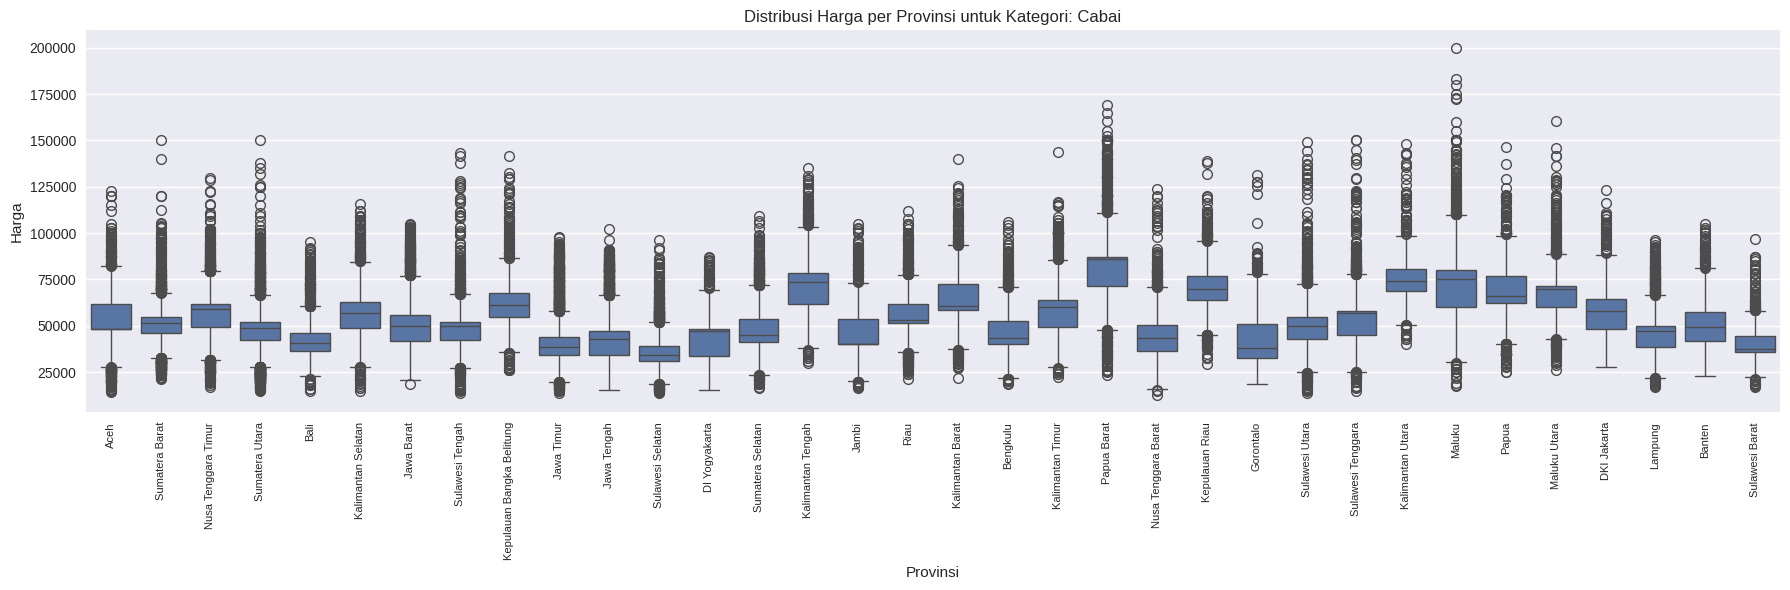

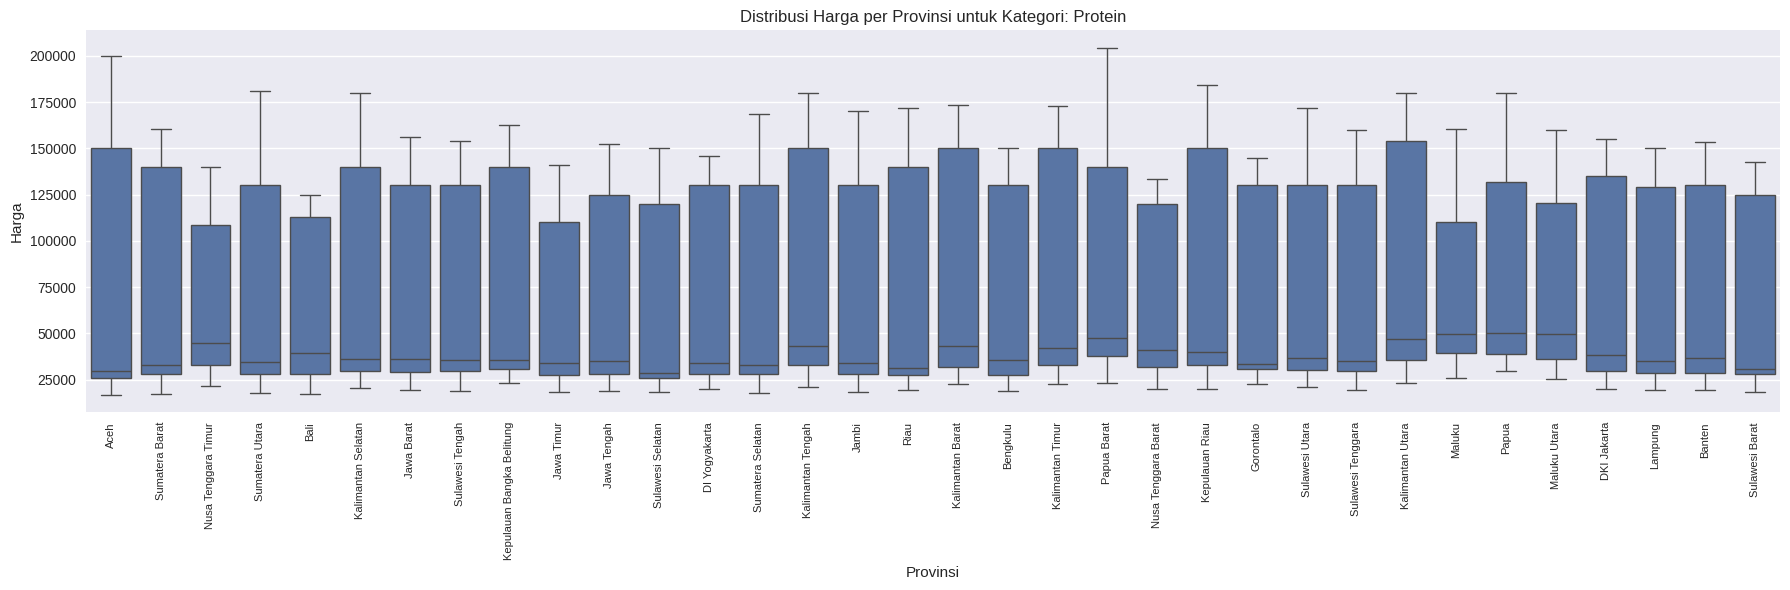

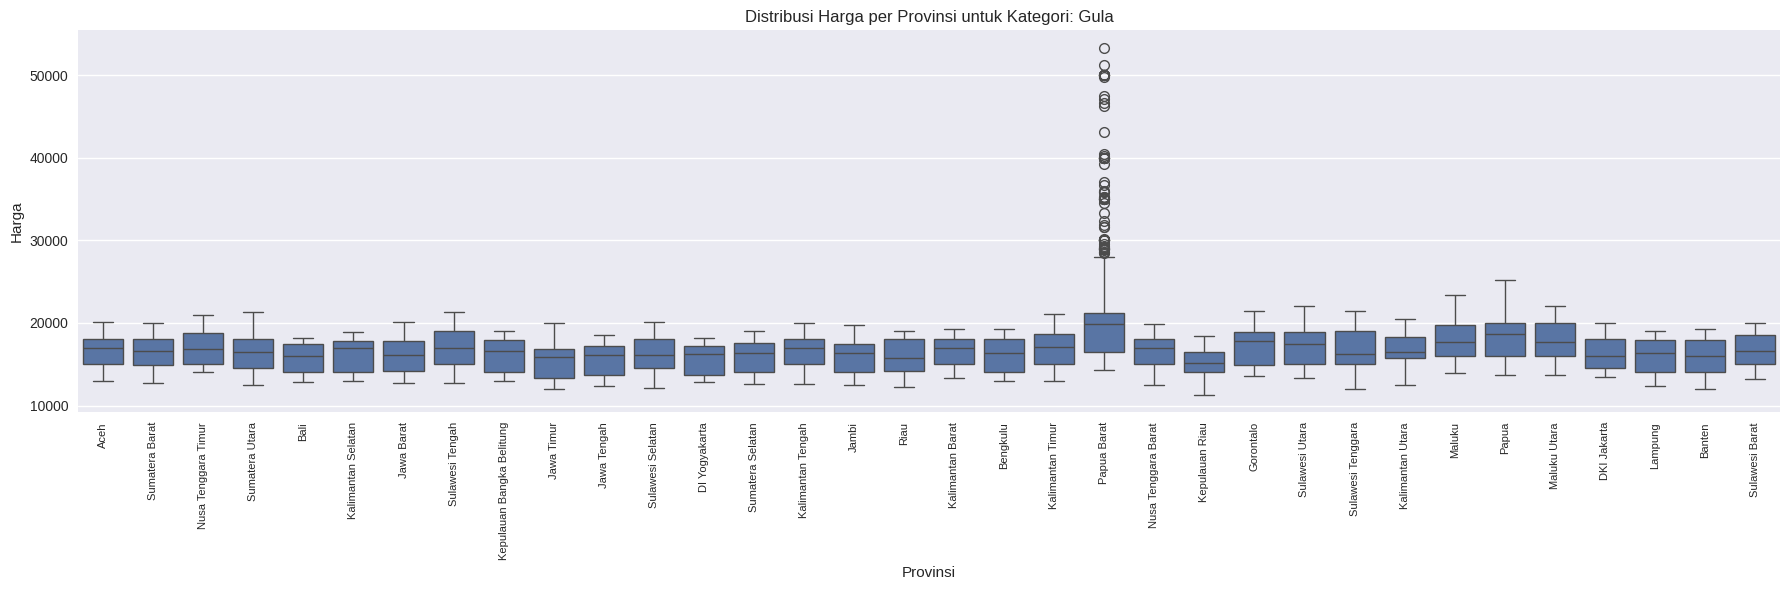

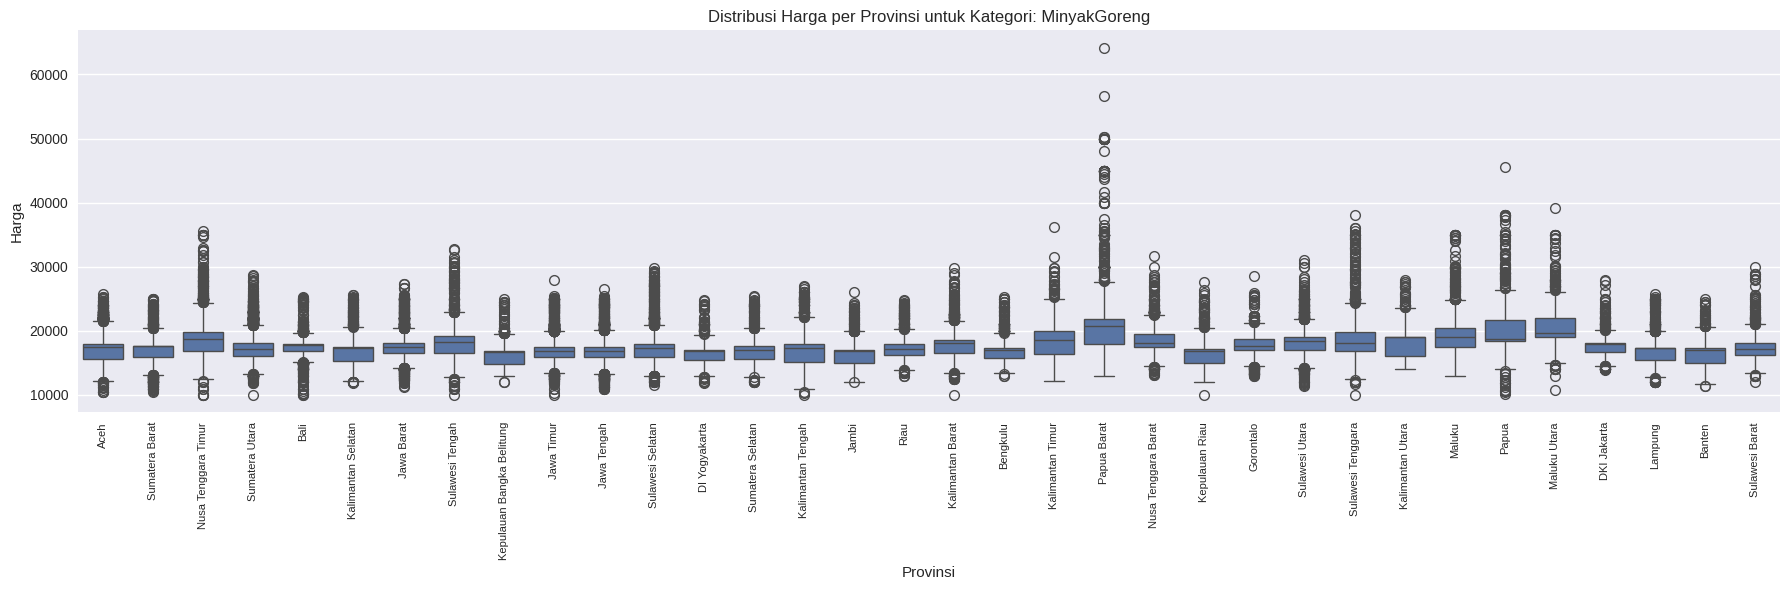

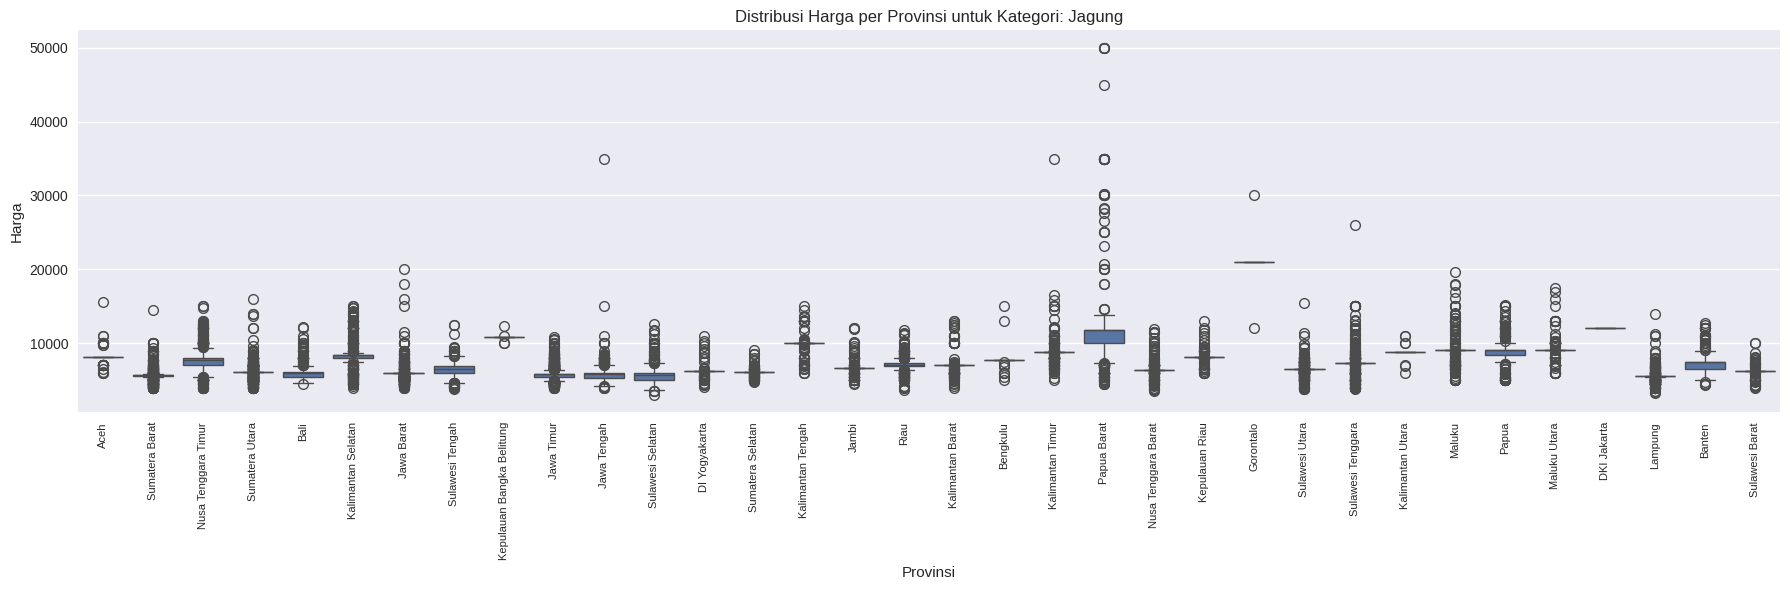

In [366]:
plt.style.use('seaborn-v0_8')

# Ambil kategori unik
unique_categories = data['Kategori'].unique()

for cat in unique_categories:
    subset = data[data['Kategori'] == cat]  # filter per kategori

    plt.figure(figsize=(18,6))
    sns.boxplot(data=subset, x='NamaProv', y='Harga')
    plt.xticks(rotation=90, fontsize=8)
    plt.title(f'Distribusi Harga per Provinsi untuk Kategori: {cat}')
    plt.xlabel('Provinsi')
    plt.ylabel('Harga')
    plt.tight_layout()
    plt.show()

boxplot sebaran harga per provinisi pada setiap kategori komoditas pangan. terlihat pada kategori beras, bawang, gula, minyak, jagung terdapat provinsi yang meiliki sebaran harga yang jauh berbeda dengan provinsi lainnya, yaitu papua barat. sedangkan untuk kategori cabai dan protein cenderung memiliki harga yang tidak jauh berbeda antar provinsi.

# K-Prototype

## Per Provinsi

In [368]:
import pandas as pd
import numpy as np
from collections import Counter
from kmodes.kprototypes import KPrototypes

In [369]:
df = data.copy()

In [370]:
# Asumsikan sudah bersih
df = df.dropna(subset=["NamaProv", "Harga"])

In [371]:
grp = df.groupby("NamaProv")

prov_df = pd.DataFrame({
    "NamaProv": grp.size().index,
    "count_obs": grp.size().values,
    "avg_harga": grp["Harga"].mean().values,
    "median_harga": grp["Harga"].median().values,
    "std_harga": grp["Harga"].std().fillna(0).values,
    "top_produk": grp["Produk"].agg(lambda x: Counter(x).most_common(1)[0][0]).values,
    "top_kategori": grp["Kategori"].agg(lambda x: Counter(x).most_common(1)[0][0]).values
})

prov_df = prov_df.reset_index(drop=True)


In [372]:
# Tentukan kolom numerik & kategorikal
num_cols = ["avg_harga", "median_harga", "std_harga", "count_obs"]
cat_cols = ["top_produk", "top_kategori"]

# Gabungkan menjadi satu matriks
X = prov_df[num_cols + cat_cols].copy()

# Konversi kategorikal ke string
for col in cat_cols:
    X[col] = X[col].astype(str)

# ubah ke numpy
X_np = X.to_numpy()

# indeks kategorikal = posisi kolom kategorikal di X
cat_idx = [X.columns.get_loc(c) for c in cat_cols]
print("Index kategori:", cat_idx)

Index kategori: [4, 5]


menginisiasikan peubah kategori dan peubah numerik yang akan digunakan pada analisis k-prototype. mengkonversi ke numpy dan mengindekskan peubah kategori untuk kebutuhan proses analisis

K=2, cost=1502614645.6713216
K=3, cost=795330040.743367
K=4, cost=616610899.9094934
K=5, cost=476824274.0768895
K=6, cost=417822676.363726
K=7, cost=343718724.0370941
K=8, cost=303562769.4525203
K=9, cost=299425552.40218484


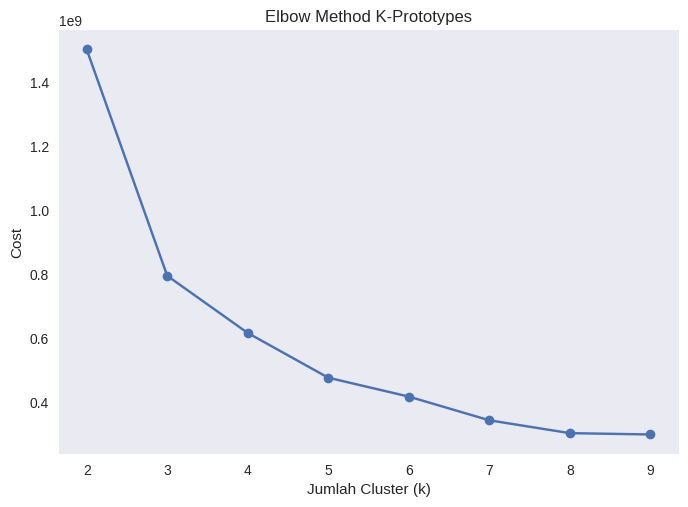

Best k = 9


In [373]:
costs = []
K_range = range(2, 10)

for k in K_range:
    model = KPrototypes(n_clusters=k, init='Huang', random_state=42)
    model.fit(X_np, categorical=cat_idx)
    costs.append(model.cost_)
    print(f"K={k}, cost={model.cost_}")

import matplotlib.pyplot as plt
plt.plot(list(K_range), costs, marker='o')
plt.title("Elbow Method K-Prototypes")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Cost")
plt.grid()
plt.show()

best_k = K_range[costs.index(min(costs))]
print("Best k =", best_k)

In [374]:
model_final = KPrototypes(n_clusters=best_k, init='Huang', random_state=42)
clusters = model_final.fit_predict(X_np, categorical=cat_idx)

prov_df["cluster"] = clusters


menggunakan metode Huang untuk analisis k-prototypenya

In [375]:
prov_df.head(40)

,NamaProv,count_obs,avg_harga,median_harga,std_harga,top_produk,top_kategori,cluster
0,Aceh,15870,35998.325307,24414.0,35394.587761,Beras Premium,Cabai,4
1,Bali,6210,31655.236823,23951.0,26313.560315,Beras Premium,Cabai,7
2,Banten,5520,34838.543432,26315.5,31459.144067,Beras Premium,Cabai,7
3,Bengkulu,6900,34000.228135,25100.0,30931.014183,Beras Premium,Cabai,7
4,DI Yogyakarta,3450,32748.806236,24077.5,30840.533364,Beras Premium,Cabai,7
5,DKI Jakarta,4140,38176.080032,27963.0,32614.812850,Beras Premium,Cabai,5
6,Gorontalo,4140,35197.968667,28819.5,29919.074839,Beras Premium,Cabai,5
7,Jambi,7590,33098.705842,24590.5,31298.160611,Beras Premium,Cabai,7
8,Jawa Barat,18630,34713.441624,26517.0,30900.449519,Beras Premium,Cabai,3
9,Jawa Tengah,23835,32436.061784,24633.0,29589.756902,Beras Premium,Cabai,3


count_obs:	Menghitung jumlah observasi per provinsi, banyaknya baris/record dari provinsi tersebut
avg_harga:	Menghitung rata-rata harga untuk semua produk dalam provinsi
median_harga:	Median harga atau Harga tengah (lebih robust terhadap outlier)
std_harga:	Standar deviasi atau variasi harga dalam satu provinsi
top_produk:	Produk yang paling sering muncul, paling dominan per provinsi
top_kategori:	Kategori paling sering muncul, paling dominan per provinsi

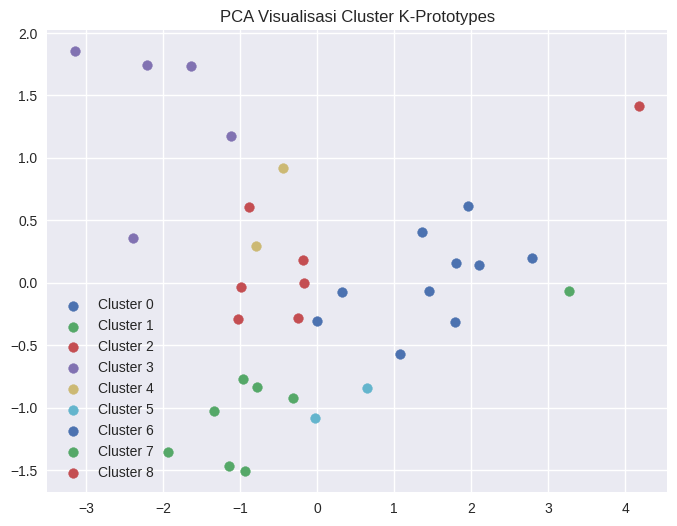

In [376]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

# encoding kategorikal
ohe = OneHotEncoder(sparse_output=False)
cat_ohe = ohe.fit_transform(prov_df[cat_cols])

# scaling numerik
scaled_num = StandardScaler().fit_transform(prov_df[num_cols])

X_pca = np.hstack([scaled_num, cat_ohe])

pc = PCA(n_components=2).fit_transform(X_pca)

plt.figure(figsize=(8,6))
for c in sorted(prov_df["cluster"].unique()):
    idx = prov_df["cluster"] == c
    plt.scatter(pc[idx,0], pc[idx,1], label=f"Cluster {c}")

plt.legend()
plt.title("PCA Visualisasi Cluster K-Prototypes")
plt.show()



melihat visualisasi cluster tapi menggunakan PCA karena tidak ada visualisasi k-prototype

In [377]:
summary = prov_df.groupby("cluster").agg({
    "avg_harga": "mean",
    "median_harga": "mean",
    "std_harga": "mean",
    "count_obs": "mean",
    "top_produk": lambda x: Counter(x).most_common(1)[0][0],
    "top_kategori": lambda x: Counter(x).most_common(1)[0][0],
})

print("===== INTERPRETASI CLUSTER =====")
print(summary)


===== INTERPRETASI CLUSTER =====
            avg_harga  median_harga     std_harga     count_obs  \
cluster                                                           
0        39354.421339  27875.357143  36166.906918   7585.714286   
1        44339.826592  32878.000000  39048.362660   3450.000000   
2        49216.835735  36500.000000  39225.450061   9915.000000   
3        32504.303479  24825.000000  29215.658662  21588.000000   
4        35544.522087  24457.000000  34082.268178  14490.000000   
5        36687.024349  28391.250000  31266.943845   4140.000000   
6        42973.100998  34205.166667  33152.437724   6780.000000   
7        33121.069433  24933.428571  29644.935291   5815.714286   
8        35350.077575  27050.916667  30578.463122  11317.500000   

            top_produk top_kategori  
cluster                              
0        Beras Premium        Cabai  
1        Beras Premium        Cabai  
2        Beras Premium        Cabai  
3        Beras Premium        Cabai  
4

melihat karakteristik setiap clusternya

## Per Observasi


mengklusterisasi pada satuan observasi, dengan menggabungkan brdasarkan produk di setiap provinsinya

In [378]:
# Hitung rata-rata harga per provinsi, kategori dan produk
prov_summary = data.groupby(["NamaProv","Kategori","Produk"]).agg({
    "Harga":"mean"
}).reset_index()

prov_summary.head()

,NamaProv,Kategori,Produk,Harga
0,Aceh,Bawang,Bawang Merah,36772.251418
1,Aceh,Bawang,Bawang Putih (Bonggol),35355.325142
2,Aceh,Beras,Beras Medium,12498.910646
3,Aceh,Beras,Beras Premium,13713.595463
4,Aceh,Cabai,Cabai Merah Besar,48069.000000


In [379]:
categorical_cols = ['NamaProv','Kategori','Produk']
numerical_cols = ['Harga']

In [380]:
for col in categorical_cols:
    prov_summary[col] = prov_summary[col].astype('category')

In [381]:
# Convert ke numpy array
matrix = prov_summary[numerical_cols + categorical_cols].to_numpy()

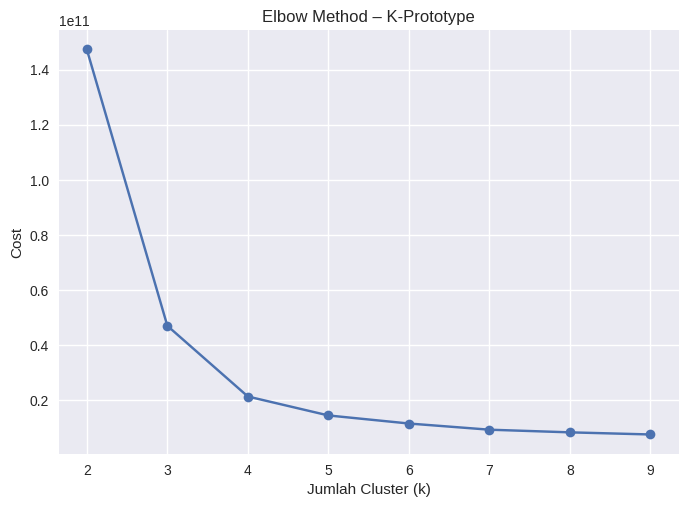

In [382]:
cost = []
K = range(2,10)

for k in K:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, verbose=0)
    kproto.fit_predict(matrix, categorical=[1,2,3])   # index categorical (setelah Harga)
    cost.append(kproto.cost_)

plt.plot(K, cost, marker='o')
plt.title("Elbow Method – K-Prototype")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Cost")
plt.show()

In [383]:
kproto = KPrototypes(n_clusters=4, init='Cao', n_init=10, verbose=1)
clusters = kproto.fit_predict(matrix, categorical=[1,2,3])

prov_summary['Cluster'] = clusters
prov_summary.head()

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 72, ncost: 21814109450.95848
Run: 1, iteration: 2/100, moves: 11, ncost: 21480867434.429813
Run: 1, iteration: 3/100, moves: 10, ncost: 21344855216.962265
Run: 1, iteration: 4/100, moves: 0, ncost: 21344855216.962265
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 254, ncost: 25807276778.985832
Run: 2, iteration: 2/100, moves: 52, ncost: 22050597126.986744
Run: 2, iteration: 3/100, moves: 13, ncost: 21625429037.81939
Run: 2, iteration: 4/100, moves: 10, ncost: 21405232460.454144
Run: 2, iteration: 5/100, moves: 5, ncost: 21344855216.96228
Run: 2, iteration: 6/100, moves: 0, ncost: 21344855216.96228
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 97, ncost: 23035157491.9866

,NamaProv,Kategori,Produk,Harga,Cluster
0,Aceh,Bawang,Bawang Merah,36772.251418,3
1,Aceh,Bawang,Bawang Putih (Bonggol),35355.325142,3
2,Aceh,Beras,Beras Medium,12498.910646,1
3,Aceh,Beras,Beras Premium,13713.595463,1
4,Aceh,Cabai,Cabai Merah Besar,48069.000000,3


menggunakan metode Cao untuk yang ini, berbeda dengan yang sebelumnya

In [384]:
cluster_profile = prov_summary.groupby("Cluster").agg({
    "Harga":"mean",
    "NamaProv":"nunique",
    "Kategori": lambda x: x.value_counts().index[0],
    "Produk": lambda x: x.value_counts().index[0]
}).reset_index()

cluster_profile

,Cluster,Harga,NamaProv,Kategori,Produk
0,0,137207.380931,34,Protein,Daging Sapi Murni
1,1,15230.961995,34,MinyakGoreng,Beras Medium
2,2,62169.282428,26,Cabai,Cabai Rawit Merah
3,3,37391.917624,34,Protein,Daging Ayam Ras


terdapat 4 cluster yang didapat. kluster 0 merupakan cluster dengan harga tertinggi, disusl kluster 2, 3, 1

In [385]:
prov_summary[['NamaProv','Cluster']].drop_duplicates().sort_values(by='Cluster')


,NamaProv,Cluster
253,Kepulauan Bangka Belitung,0
148,Jawa Tengah,0
163,Jawa Timur,0
178,Kalimantan Barat,0
193,Kalimantan Selatan,0
...,...,...
372,Papua Barat,3
375,Riau,3
390,Sulawesi Barat,3
405,Sulawesi Selatan,3


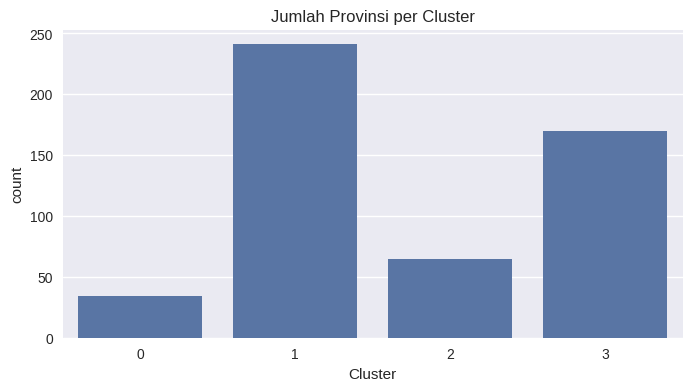

In [386]:
import seaborn as sns
plt.figure(figsize=(8,4))
sns.countplot(x='Cluster', data=prov_summary)
plt.title("Jumlah Provinsi per Cluster")
plt.show()


cluster 1 memiliki observasi terbanyak, kemudian disusul 3, 2, dan 1.